In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import shuffle
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt
import time
from os import listdir

%matplotlib inline

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import imutils
import matplotlib.pyplot as plt
from os import listdir
import time

%matplotlib inline

#Data Augmentation

In [7]:
# Nicely formatted time string
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{round(s,1)}"

In [11]:
import os
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from os import listdir

def augment_data(file_dir, n_generated_samples, save_to_dir):
    """
    Arguments:
        file_dir: A string representing the directory where images that we want to augment are found.
        n_generated_samples: A string representing the number of generated samples using the given image.
        save_to_dir: A string representing the directory in which the generated images will be saved.
    """

    # Create the save_to_dir if it doesn't exist
    if not os.path.exists(save_to_dir):
        os.makedirs(save_to_dir)

    data_gen = ImageDataGenerator(rotation_range=10,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  shear_range=0.1,
                                  brightness_range=(0.3, 1.0),
                                  horizontal_flip=True,
                                  vertical_flip=True,
                                  fill_mode='nearest'
                                 )


    for filename in listdir(file_dir):
        # load the image
        image_path = os.path.join(file_dir, filename)
        image = cv2.imread(image_path)

        # Check if image loading was successful
        if image is None:
            print(f"Warning: Could not load image {image_path}. Skipping.")
            continue

        # reshape the image
        image = image.reshape((1,)+image.shape)
        # prefix of the names for the generated sampels.
        save_prefix = 'aug_' + filename[:-4]
        # generate 'n_generated_samples' sample images
        i=0
        for batch in data_gen.flow(x=image, batch_size=1, save_to_dir=save_to_dir,
                                           save_prefix=save_prefix, save_format='jpg'):
            i += 1
            if i > n_generated_samples:
                break

In [15]:
start_time = time.time()

augmented_data_path = 'augmented data/'

# augment data for the examples with label equal to 'yes' representing tumurous examples
augment_data(file_dir='/content/drive/MyDrive/Project/DiagnosisAI/brain_tumor_dataset/yes', n_generated_samples=6, save_to_dir=augmented_data_path+'yes')
# augment data for the examples with label equal to 'no' representing non-tumurous examples
augment_data(file_dir='/content/drive/MyDrive/Project/DiagnosisAI/brain_tumor_dataset/no', n_generated_samples=9, save_to_dir=augmented_data_path+'no')

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Elapsed time: 0:2:56.9


In [12]:
def data_summary(main_path):

    yes_path = main_path+'yes'
    no_path = main_path+'no'

    # number of files (images) that are in the the folder named 'yes' that represent tumorous (positive) examples
    m_pos = len(listdir(yes_path))
    # number of files (images) that are in the the folder named 'no' that represent non-tumorous (negative) examples
    m_neg = len(listdir(no_path))
    # number of all examples
    m = (m_pos+m_neg)

    pos_prec = (m_pos* 100.0)/ m
    neg_prec = (m_neg* 100.0)/ m

    print(f"Number of examples: {m}")
    print(f"Percentage of positive examples: {pos_prec}%, number of pos examples: {m_pos}")
    print(f"Percentage of negative examples: {neg_prec}%, number of neg examples: {m_neg}")

In [18]:
data_summary(augmented_data_path)

Number of examples: 2065
Percentage of positive examples: 52.54237288135593%, number of pos examples: 1085
Percentage of negative examples: 47.45762711864407%, number of neg examples: 980


In [11]:
def crop_brain_contour(image, plot=False):

    #import imutils
    #import cv2
    #from matplotlib import pyplot as plt

    # Convert the image to grayscale, and blur it slightly
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Threshold the image, then perform a series of erosions +
    # dilations to remove any small regions of noise
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find contours in thresholded image, then grab the largest one
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)


    # Find the extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # crop new image out of the original image using the four extreme points (left, right, top, bottom)
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    if plot:
        plt.figure()

        plt.subplot(1, 2, 1)
        plt.imshow(image)

        plt.tick_params(axis='both', which='both',
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Original Image')

        plt.subplot(1, 2, 2)
        plt.imshow(new_image)

        plt.tick_params(axis='both', which='both',
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Cropped Image')

        plt.show()

    return new_image

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


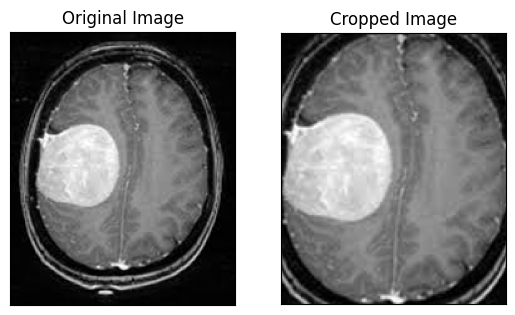

In [20]:
ex_img = cv2.imread('/content/drive/MyDrive/Project/DiagnosisAI/brain_tumor_dataset/yes/Y1.jpg')
ex_new_img = crop_brain_contour(ex_img, True)


In [9]:
import os

def load_data(dir_list, image_size):
    """
    Read images, resize and normalize them.
    Arguments:
        dir_list: list of strings representing file directories.
    Returns:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    """

    # load all images in a directory
    X = []
    y = []
    image_width, image_height = image_size

    for directory in dir_list:
        for filename in listdir(directory):
            # load the image
            image_path = os.path.join(directory, filename)
            image = cv2.imread(image_path)
            # crop the brain and ignore the unnecessary rest part of the image
            image = crop_brain_contour(image, plot=False)
            # resize image
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC)
            # normalize values
            image = image / 255.
            # convert image to numpy array and append it to X
            X.append(image)
            # append a value of 1 to the target array if the image
            # is in the folder named 'yes', otherwise append 0.
            if directory[-3:] == 'yes':
                y.append([1])
            else:
                y.append([0])

    X = np.array(X)
    y = np.array(y)

    # Shuffle the data
    X, y = shuffle(X, y)

    print(f'Number of examples is: {len(X)}')
    print(f'X shape is: {X.shape}')
    print(f'y shape is: {y.shape}')

    return X, y

In [13]:
augmented_path = '/content/augmented data'

# augmented data (yes and no) contains both the original and the new generated examples
augmented_yes = augmented_path + '/yes'
augmented_no = augmented_path + '/no'

IMG_WIDTH, IMG_HEIGHT = (240, 240)

X, y = load_data([augmented_yes, augmented_no], (IMG_WIDTH, IMG_HEIGHT))

Number of examples is: 2065
X shape is: (2065, 240, 240, 3)
y shape is: (2065, 1)


In [14]:
def plot_sample_images(X, y, n=50):
    """
    Plots n sample images for both values of y (labels).
    Arguments:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    """

    for label in [0,1]:
        # grab the first n images with the corresponding y values equal to label
        images = X[np.argwhere(y == label)]
        n_images = images[:n]

        columns_n = 10
        rows_n = int(n/ columns_n)

        plt.figure(figsize=(20, 10))

        i = 1 # current plot
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])

            # remove ticks
            plt.tick_params(axis='both', which='both',
                            top=False, bottom=False, left=False, right=False,
                           labelbottom=False, labeltop=False, labelleft=False, labelright=False)

            i += 1

        label_to_str = lambda label: "Yes" if label == 1 else "No"
        plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

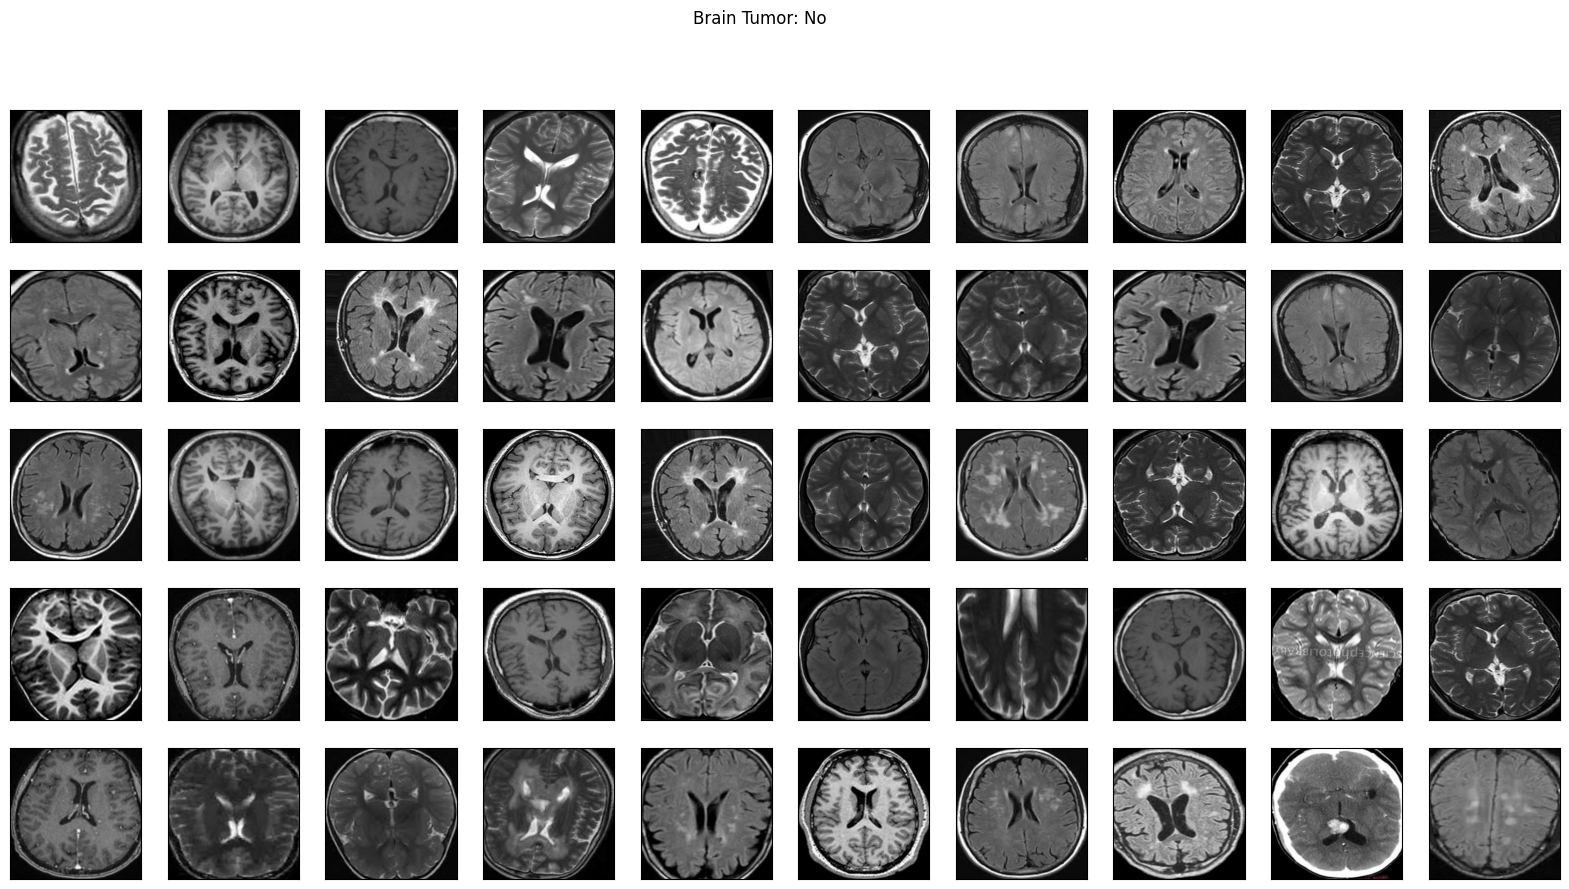

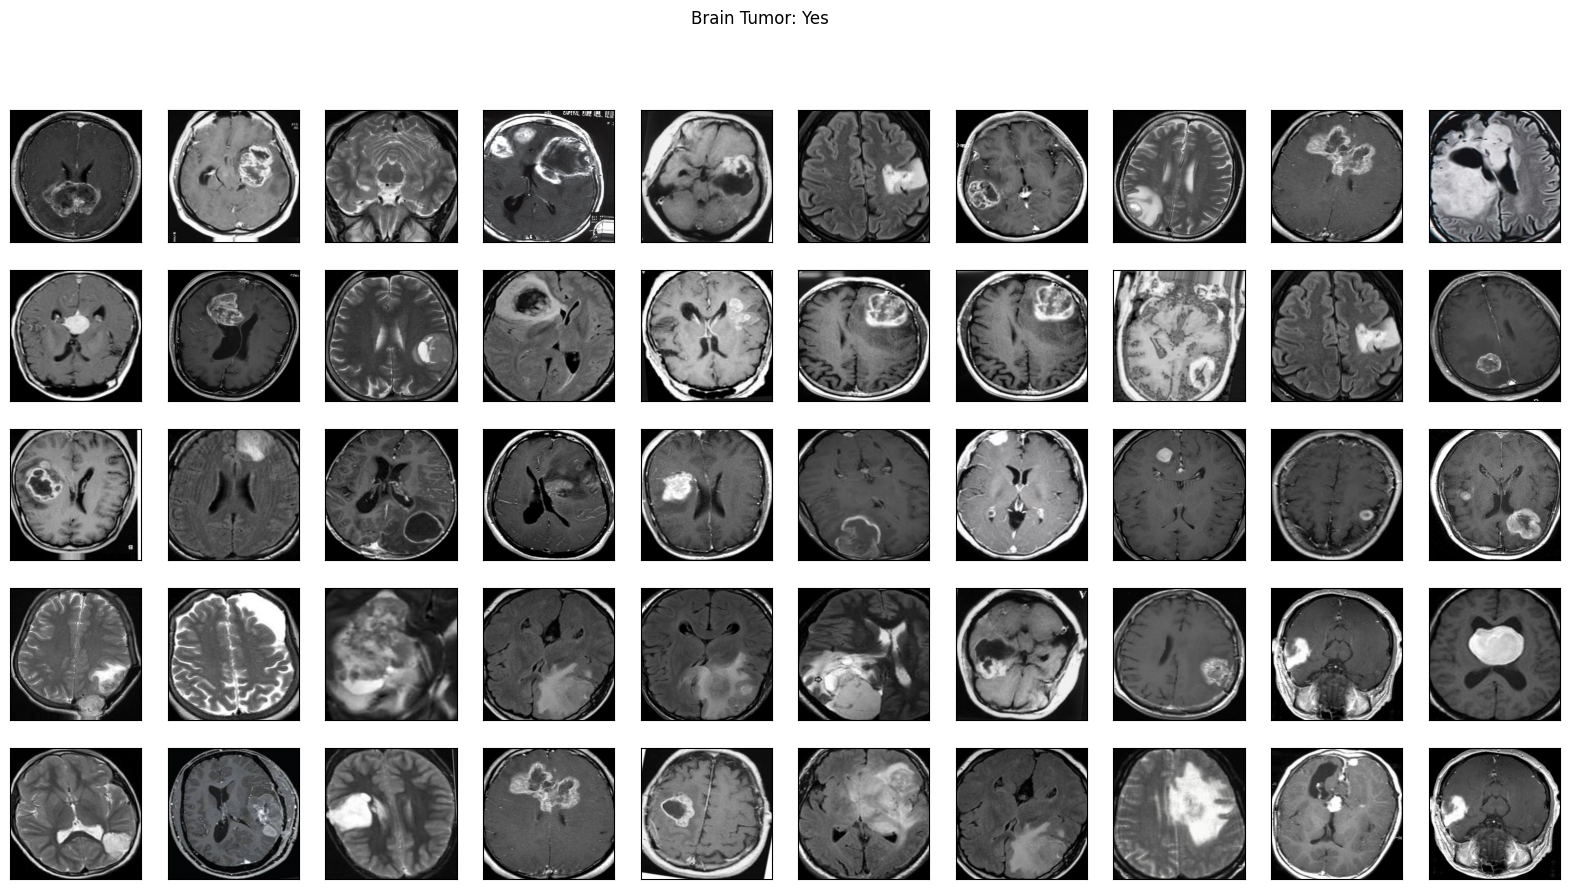

In [24]:
plot_sample_images(X, y)

In [15]:
def split_data(X, y, test_size=0.2):

    """
    Splits data into training, development and test sets.
    Arguments:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    Returns:
        X_train: A numpy array with shape = (#_train_examples, image_width, image_height, #_channels)
        y_train: A numpy array with shape = (#_train_examples, 1)
        X_val: A numpy array with shape = (#_val_examples, image_width, image_height, #_channels)
        y_val: A numpy array with shape = (#_val_examples, 1)
        X_test: A numpy array with shape = (#_test_examples, image_width, image_height, #_channels)
        y_test: A numpy array with shape = (#_test_examples, 1)
    """

    X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=test_size)
    X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5)

    return X_train, y_train, X_val, y_val, X_test, y_test

In [16]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y, test_size=0.3)

In [17]:
print ("number of training examples = " + str(X_train.shape[0]))
print ("number of development examples = " + str(X_val.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(y_train.shape))
print ("X_val (dev) shape: " + str(X_val.shape))
print ("Y_val (dev) shape: " + str(y_val.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(y_test.shape))

number of training examples = 1445
number of development examples = 310
number of test examples = 310
X_train shape: (1445, 240, 240, 3)
Y_train shape: (1445, 1)
X_val (dev) shape: (310, 240, 240, 3)
Y_val (dev) shape: (310, 1)
X_test shape: (310, 240, 240, 3)
Y_test shape: (310, 1)


In [18]:
# Nicely formatted time string
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{round(s,1)}"

In [19]:
def compute_f1_score(y_true, prob):
    # convert the vector of probabilities to a target vector
    y_pred = np.where(prob > 0.5, 1, 0)

    score = f1_score(y_true, y_pred)

    return score

###focal loss function

In [21]:
import tensorflow as tf

def focal_loss(alpha=0.75, gamma=2.0):   # alpha>0.5 biases towards positives
    def fl(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        loss = - alpha_t * tf.pow(1. - p_t, gamma) * tf.math.log(p_t)
        return tf.reduce_mean(loss)
    return fl


Resnet-50 model

In [22]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Load the pre-trained ResNet50 model without the top (classification) layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(240, 240, 3))

# Freeze the pre-trained layers
for layer in base_model.layers:
    layer.trainable = False



from sklearn.utils import class_weight
import numpy as np
classes = np.unique(y_train.flatten())
cw = class_weight.compute_class_weight('balanced', classes=classes, y=y_train.flatten())
class_weights = {i: cw_i for i, cw_i in enumerate(cw)}
print('Class weights:', class_weights)


# Add custom classification head with Batch Normalization and Dropout
x = GlobalAveragePooling2D()(base_model.output)        # Reduce spatial dimensions
x = Dense(256, activation='relu')(x)                   # Fully connected layer
x = BatchNormalization()(x)                            # Normalize activations
x = Dropout(0.5)(x)                                    # Regularization to prevent overfitting
output = Dense(1, activation='sigmoid')(x)              # Binary output layer

# Create the full model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss=focal_loss(),
              metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()])

# Display model summary
model.summary()


es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
rlp = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)
ckpt = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

# Train the model for 15 epochs
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,                    # more epochs; EarlyStopping will stop earlier if needed
    batch_size=32,                # increase if GPU memory allows
    callbacks=[es, rlp, ckpt],
    class_weight=class_weights,   # helps if you don't want focal loss; safe to keep
    verbose=1
)

# Evaluate the model on the test set
test_loss, test_accuracy, test_recall, test_precision = model.evaluate(X_test, y_test)
print("\n📊 Test Results:")
print("Loss:", test_loss)
print("Accuracy:", test_accuracy)
print("Recall:", test_recall)
print("Precision:", test_precision)

# Optional: Save the trained model
# model.save('Model/resnet50_brain_tumor_detection_with_bn.h5')

Class weights: {0: np.float64(1.0440751445086704), 1: np.float64(0.9594953519256308)}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 246, 246,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 120, 120,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 120, 120,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 120, 120,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 122, 122,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 60, 60,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 60, 60,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 60, 60,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 60, 60,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 60, 60,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 60, 60,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 60, 60,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 60, 60,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 60, 60,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 60, 60,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 60, 60,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

...

46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.6959 - loss: 0.0617 - precision: 0.6531 - recall: 0.9097 - val_accuracy: 0.7129 - val_loss: 0.0526 - val_precision: 0.6549 - val_recall: 0.9308 - learning_rate: 3.0000e-04
Epoch 10/30
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6890 - loss: 0.0661 - precision: 0.6285 - recall: 0.8817
Epoch 10: val_loss did not improve from 0.05256
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.6895 - loss: 0.0661 - precision: 0.6297 - recall: 0.8819 - val_accuracy: 0.7548 - val_loss: 0.0676 - val_precision: 0.8029 - val_recall: 0.6918 - learning_rate: 3.0000e-04
Epoch 11/30
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7205 - loss: 0.0551 - precision: 0.6672 - recall: 0.9236
Epoch 11: val_loss improved from 0.05256 to 0.05238, saving model to best_model.h5


46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.7207 - loss: 0.0551 - precision: 0.6674 - recall: 0.9239 - val_accuracy: 0.7548 - val_loss: 0.0524 - val_precision: 0.7024 - val_recall: 0.9057 - learning_rate: 3.0000e-04
Epoch 12/30
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7506 - loss: 0.0506 - precision: 0.6955 - recall: 0.9277
Epoch 12: val_loss did not improve from 0.05238
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.7502 - loss: 0.0506 - precision: 0.6951 - recall: 0.9276 - val_accuracy: 0.7516 - val_loss: 0.0589 - val_precision: 0.7412 - val_recall: 0.7925 - learning_rate: 3.0000e-04
Epoch 13/30
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7217 - loss: 0.0573 - precision: 0.6819 - recall: 0.9061
Epoch 13: val_loss did not improve from 0.05238
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.7214 - loss: 0.0573 - precision: 0.6812 - recall: 0.9064 - val_accuracy: 0.6032 - val_loss: 0.0695 - val_precision: 0.5652 - val_recall: 0.9811 - lea

46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.7618 - loss: 0.0497 - precision: 0.6986 - recall: 0.9342 - val_accuracy: 0.6742 - val_loss: 0.0520 - val_precision: 0.6151 - val_recall: 0.9748 - learning_rate: 9.0000e-05
Epoch 16/30
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7261 - loss: 0.0521 - precision: 0.6648 - recall: 0.9389
Epoch 16: val_loss improved from 0.05203 to 0.05059, saving model to best_model.h5


46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.7269 - loss: 0.0522 - precision: 0.6659 - recall: 0.9381 - val_accuracy: 0.6871 - val_loss: 0.0506 - val_precision: 0.6260 - val_recall: 0.9686 - learning_rate: 9.0000e-05
Epoch 17/30
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7708 - loss: 0.0476 - precision: 0.7137 - recall: 0.9385
Epoch 17: val_loss did not improve from 0.05059
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.7704 - loss: 0.0477 - precision: 0.7134 - recall: 0.9379 - val_accuracy: 0.6355 - val_loss: 0.0611 - val_precision: 0.5852 - val_recall: 0.9937 - learning_rate: 9.0000e-05
Epoch 18/30
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7573 - loss: 0.0485 - precision: 0.7018 - recall: 0.9236
Epoch 18: val_loss did not improve from 0.05059
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.7577 - loss: 0.0485 - precision: 0.7021 - recall: 0.9241 - val_accuracy: 0.6613 - val_loss: 0.0535 - val_precision: 0.6055 - val_recall: 0.9748 - lea

46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.7658 - loss: 0.0468 - precision: 0.7128 - recall: 0.9232 - val_accuracy: 0.7194 - val_loss: 0.0487 - val_precision: 0.6552 - val_recall: 0.9560 - learning_rate: 9.0000e-05
Epoch 20/30
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7629 - loss: 0.0517 - precision: 0.7121 - recall: 0.9115
Epoch 20: val_loss did not improve from 0.04871
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.7632 - loss: 0.0515 - precision: 0.7123 - recall: 0.9118 - val_accuracy: 0.7194 - val_loss: 0.0493 - val_precision: 0.6748 - val_recall: 0.8742 - learning_rate: 9.0000e-05
Epoch 21/30
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7369 - loss: 0.0533 - precision: 0.6900 - recall: 0.9020
Epoch 21: val_loss did not improve from 0.04871
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.7379 - loss: 0.0530 - precision: 0.6906 - recall: 0.9031 - val_accuracy: 0.6516 - val_loss: 0.0574 - val_precision: 0.5977 - val_recall: 0.9811 - le

In [23]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 231ms/step - accuracy: 0.7654 - loss: 0.0463 - precision: 0.7150 - recall: 0.9250 - val_accuracy: 0.7194 - val_loss: 0.0485 - val_precision: 0.6593 - val_recall: 0.9371
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.7622 - loss: 0.0483 - precision: 0.7170 - recall: 0.9167 - val_accuracy: 0.7226 - val_loss: 0.0487 - val_precision: 0.6594 - val_recall: 0.9497
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.7575 - loss: 0.0447 - precision: 0.7017 - recall: 0.9279 - val_accuracy: 0.7194 - val_loss: 0.0486 - val_precision: 0.6579 - val_recall: 0.9434
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.7660 - loss: 0.0467 - precision: 0.7159 - recall: 0.9124 - val_accuracy: 0.7290 - val_loss: 0.0484 - val_precision: 0.6682 - val_recall: 0.9371
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.7455 - loss: 0.0489 - precision: 0.6867 - recall: 0.9141 - val_accuracy: 0.7194 - val_loss: 0

In [24]:
loss, acc, recall, precision = model.evaluate(x=X_test, y=y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.7451 - loss: 0.0476 - precision: 0.6951 - recall: 0.9290


In [25]:
def plot_metrics(history):

    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    # Loss
    plt.figure()
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(train_acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

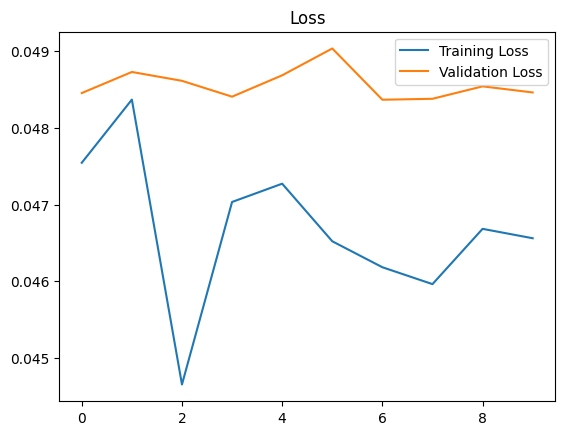

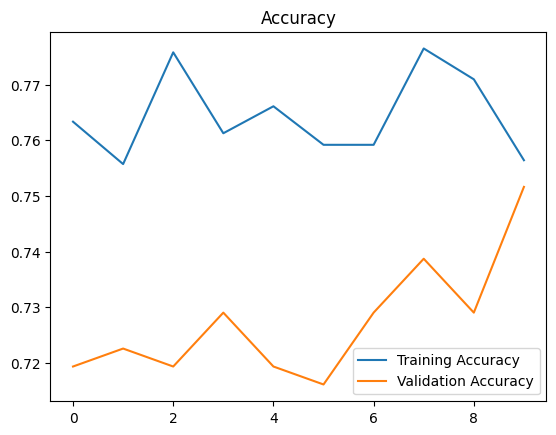

In [26]:
plot_metrics(history)

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 503ms/step


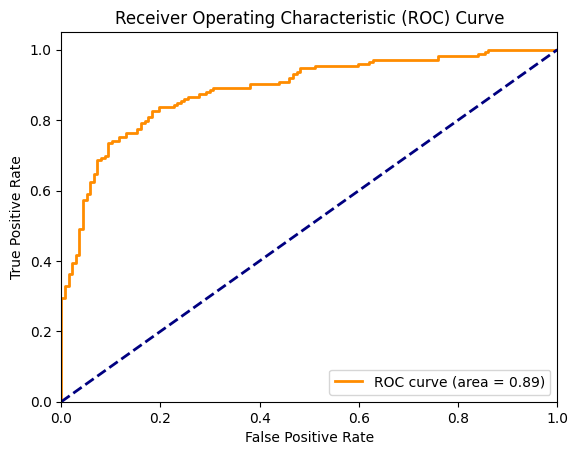

In [27]:
from sklearn.metrics import roc_curve, auc

# Assuming you have your test data in X_test and true labels in y_test

# Make predictions on the test set
y_pred_probs = model.predict(X_test)

# Calculate True Positive Rate (TPR) and False Positive Rate (FPR)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


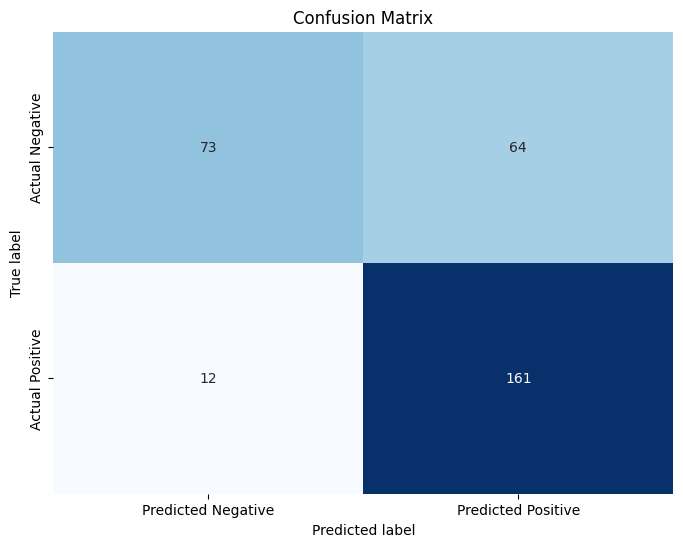

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(X_test)

# Threshold predicted probabilities to obtain binary predictions
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_binary)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


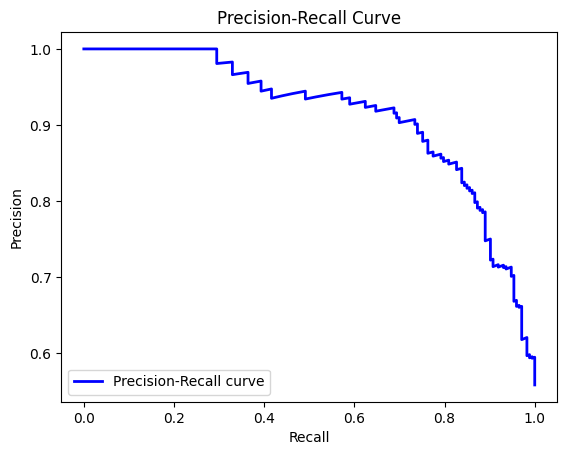

In [29]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Assuming you have your test data in X_test and true labels in y_test
# Assuming you have your trained model stored in 'model'

# Make predictions on the test set
y_pred_probs = model.predict(X_test)

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)

# Plot Precision-Recall curve
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()